# LAB 1: AVPR
Óscar Cubeles Ollé

In [96]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

spongebob_img_path = "..\data\Spongebob.jpg"
peppers_img_path = f"..\data\peppers.png"

In [97]:
img = cv2.imread(spongebob_img_path,  cv2.IMREAD_GRAYSCALE)

## Task 1: Edge Detection Comparison

In [98]:
def apply_edge_detection(img, horizontal_kernel, vertical_kernel):

    # Apply convolution using the given kernels
    horizontal_edges = cv2.filter2D(img, -1, horizontal_kernel)
    vertical_edges = cv2.filter2D(img, -1, vertical_kernel)

    # Combine edges using magnitude
    combined_edges = np.sqrt(horizontal_edges**2 +
                             vertical_edges**2)
    #combined_edges = np.uint8(np.clip(combined_edges, 0, 255))

    # Display results
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes[0, 0].imshow(img, cmap='gray')
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(horizontal_edges, cmap='gray')
    axes[0, 1].set_title('Horizontal Edges')
    axes[0, 1].axis('off')

    axes[1, 0].imshow(vertical_edges, cmap='gray')
    axes[1, 0].set_title('Vertical Edges')
    axes[1, 0].axis('off')

    axes[1, 1].imshow(combined_edges, cmap='gray')
    axes[1, 1].set_title('Combined Edges')
    axes[1, 1].axis('off')

    plt.tight_layout()
    plt.show()

    return combined_edges


### Sobel Edge Detection

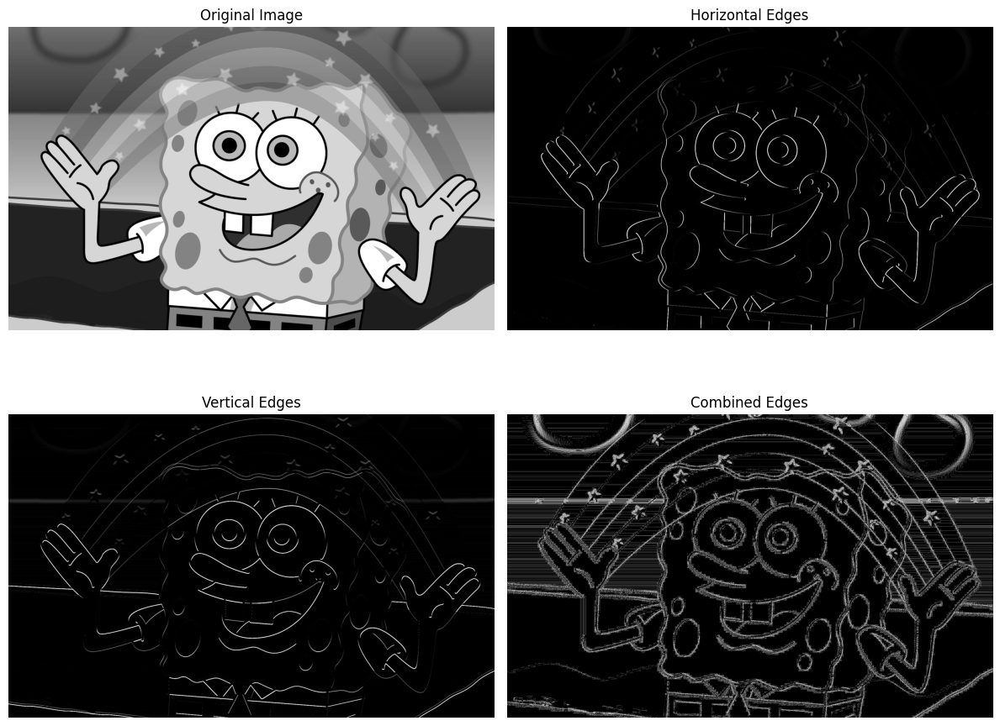

In [99]:
sob_horizontal_kernel = np.array([[-1, 0, 1],
                              [-2, 0, 2],
                              [-1, 0, 1]], dtype=np.float32)
sob_vertical_kernel = np.array([[-1, -2, -1],
                            [0, 0, 0],
                            [1, 2, 1]], dtype=np.float32)


sobel_combined_edges = apply_edge_detection(img, sob_horizontal_kernel, sob_vertical_kernel)

### Prewit Edge Detection

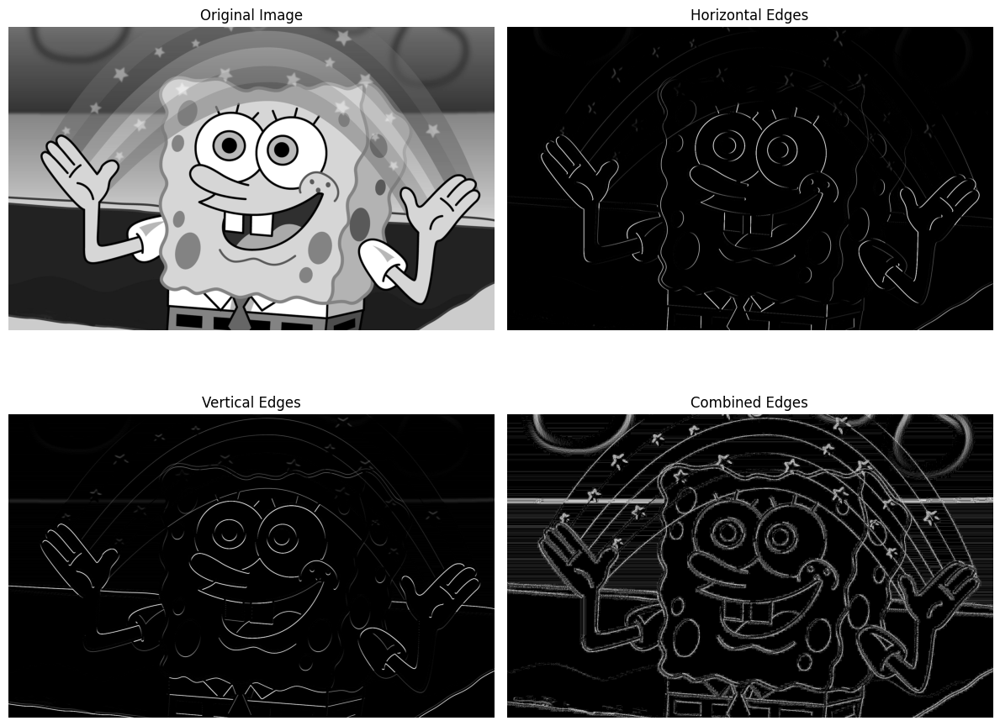

In [100]:
prewitt_x = np.array([[-1, 0, 1],
                      [-1, 0, 1],
                      [-1, 0, 1]], dtype=np.float32)
prewitt_y = np.array([[-1, -1, -1],
                      [0, 0, 0],
                      [1, 1, 1]], dtype=np.float32)


prewitt_combined_edges = apply_edge_detection(img, prewitt_x, prewitt_y)

### Scharr Operator

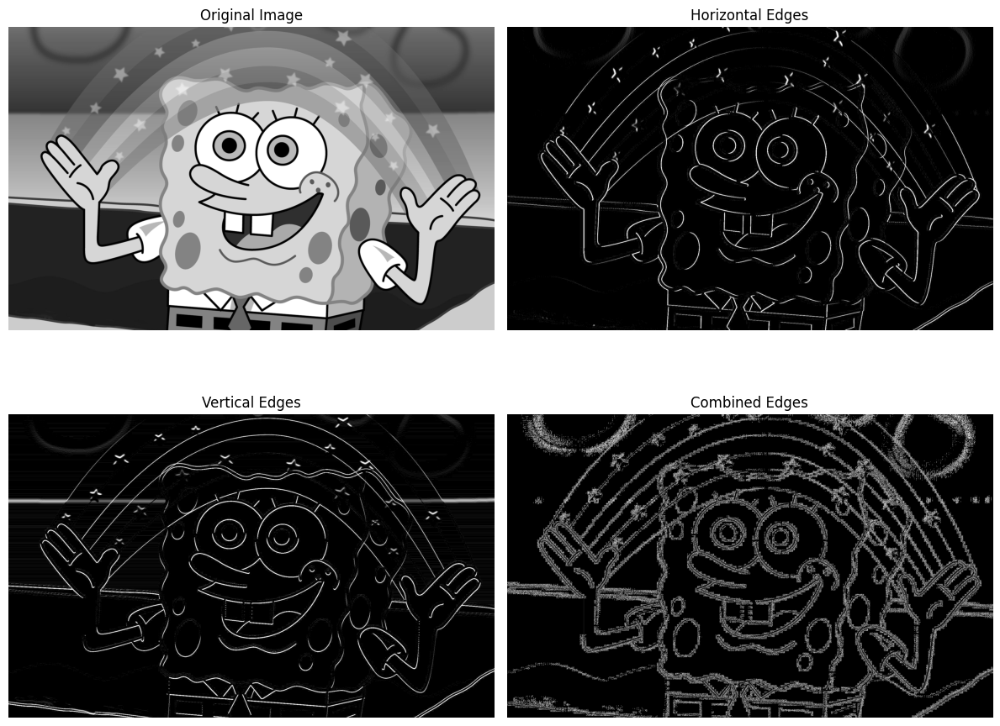

In [101]:
# Scharr operator
scharr_x = np.array([[-3, 0, 3],
                     [-10, 0, 10],
                     [-3, 0, 3]], dtype=np.float32)
scharr_y = np.array([[-3, -10, -3],
                     [0, 0, 0],
                     [3, 10, 3]], dtype=np.float32)
scharr_combined_edges = apply_edge_detection(img, scharr_x, scharr_y)

### Edge Detection Comparison

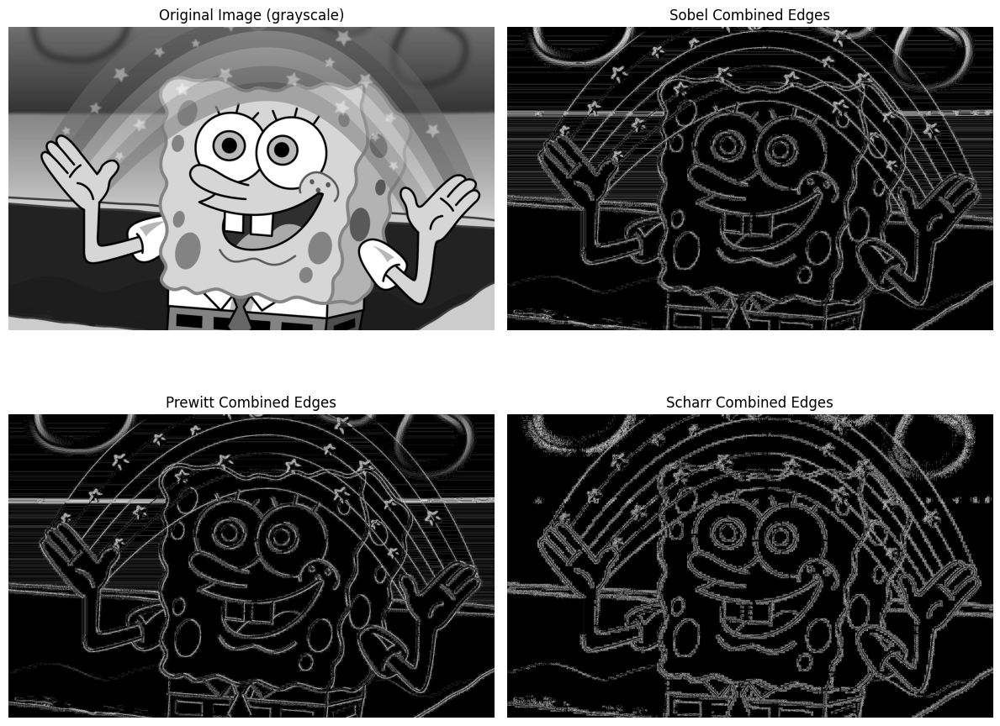

In [102]:
# Display results
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title('Original Image (grayscale)')
axes[0, 0].axis('off')

axes[0, 1].imshow(sobel_combined_edges, cmap='gray')
axes[0, 1].set_title('Sobel Combined Edges')
axes[0, 1].axis('off')

axes[1, 0].imshow(prewitt_combined_edges, cmap='gray')
axes[1, 0].set_title('Prewitt Combined Edges')
axes[1, 0].axis('off')

axes[1, 1].imshow(scharr_combined_edges, cmap='gray')
axes[1, 1].set_title('Scharr Combined Edges')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

With a visual comparison, shcarr operator clearly detects edges with more intensity, and for this case the result is a bit noisy. I would say that for the image I selected the best approach is prewitt edge detection, as it provides a less blurry result. 

## Task 2: Custom Kernel Design and Application

- Sharpening Kernel: Have a high value in the middle to focus on taking the centre pixel mor into consideration
- Edge Enhancement Kernel
- Emboss Kernel: gives an image a 3D relief effect emphazising opposite side of edges
- Custom Blur Kernel

In [103]:
def display_kernels(img, kernels, kernel_names, rows=2):
    n = len(kernels)
    cols = (n + 1) // rows + ((n + 1) % rows > 0)

    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes = axes.flatten()

    axes[0].imshow(img, cmap='gray')
    axes[0].set_title('Original')
    axes[0].axis('off')

    for i, (kernel, title) in enumerate(zip(kernels, kernel_names)):
        filtered = cv2.filter2D(img, -1, kernel)
        axes[i+1].imshow(filtered, cmap='gray')
        axes[i+1].set_title(title)
        axes[i+1].axis('off')

    for j in range(i+2, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

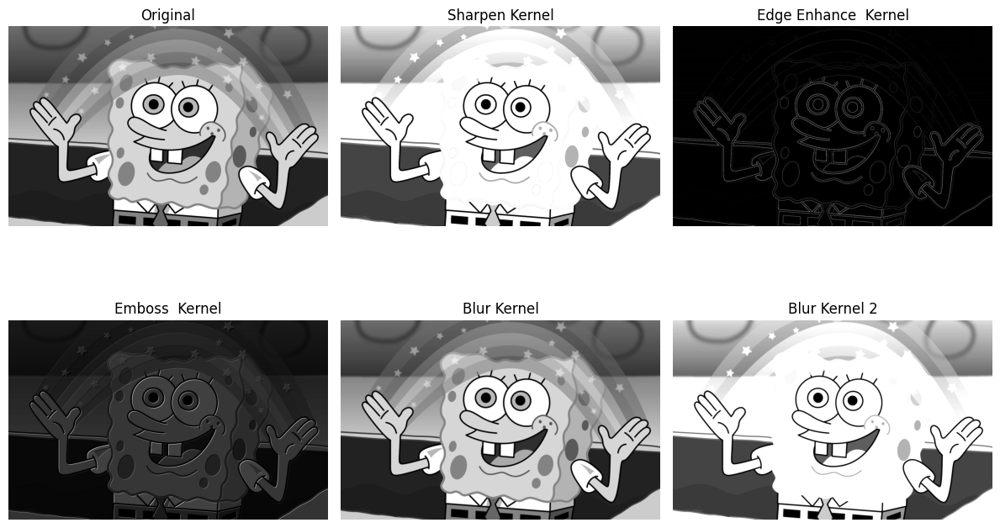

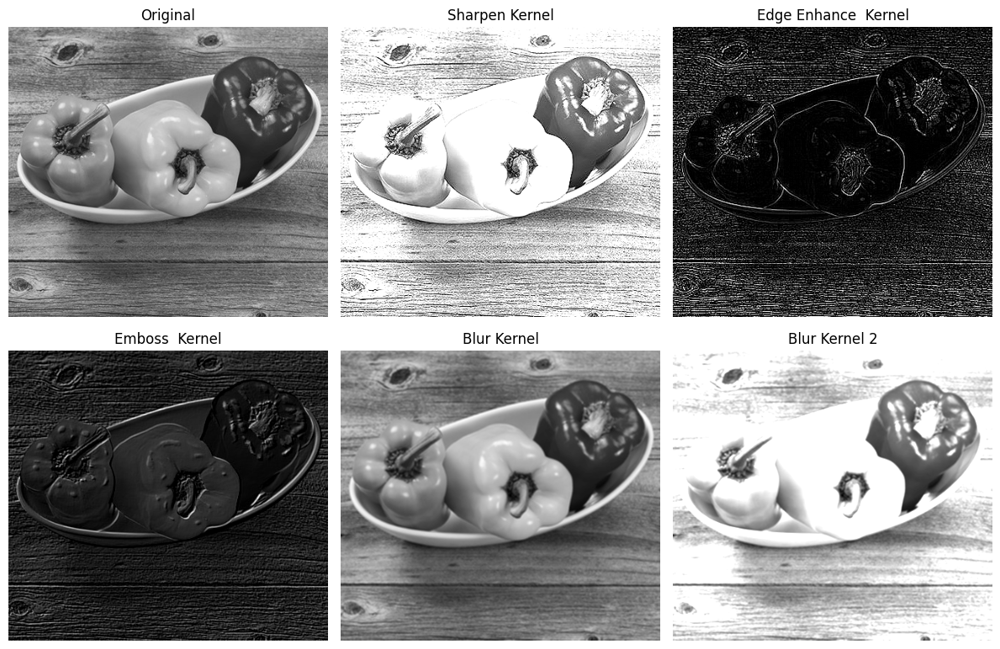

In [104]:
kernels = [
    np.array([[0, -1, 0], [-1, 6, -1], [0, -1, 0]], dtype=np.float32),  # Sharpen
    np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]], dtype=np.float32),  # Edge enhance
    np.array([[-3, -1, 0], [-1, 1, 1], [0, 1, 3]], dtype=np.float32) / 4,  # emboss
    np.array([
            [1, 1, 1],
            [1, 1, 1],
            [1, 1, 1]
        ], dtype=np.float32) / 9, # custom blur kernel
    np.array([
            [2, 2, 2],
            [2, 2, 2],
            [2, 2, 2]
        ], dtype=np.float32) / 9 # custom blur kernel
]
kernel_names = ['Sharpen Kernel', 'Edge Enhance  Kernel', 'Emboss  Kernel', 'Blur Kernel', 'Blur Kernel 2']
img2 = cv2.imread(peppers_img_path,  cv2.IMREAD_GRAYSCALE)
display_kernels(img, kernels, kernel_names, rows=2)
display_kernels(img2, kernels, kernel_names, rows=2)

When trying with different kernels on different images, I observe different effects, blur kernels smooth the image which reduce the  detail but also produces an image with less noise. The emboss kernel creates a 3D relief effect and the sharpen kernel enhances edges and contrast, making the image appear brighter. Finally the edge enhancement kernel emphasizes boundaries, highlighting edges and producing a similar result to the a single axis kernels of Task1.

## Task 3: Noise Addition and Reduction Analysis

In [105]:
def add_salt_pepper_noise(img, amount=0.05):
    noisy_img = img.copy()
    num_salt = np.ceil(amount * img.size * 0.5).astype(int)
    num_pepper = np.ceil(amount * img.size * 0.5).astype(int)

    # Salt noise
    coords = [np.random.randint(0, i, num_salt) for i in img.shape]
    noisy_img[coords[0], coords[1]] = 255

    # Pepper noise
    coords = [np.random.randint(0, i, num_pepper) for i in img.shape]
    noisy_img[coords[0], coords[1]] = 0

    return noisy_img

In [106]:
# Calculate PSNR (Peak Signal-to-Noise Ratio)
# High PSNR -> processed image close to original
# Low PSNR -> processed image not close to original
def calculate_psnr(original, filtered):
    mse = np.mean((original.astype(float) - filtered.astype(float)) ** 2)
    if mse == 0:
        return float('inf')
    max_pixel = 255.0
    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
    return psnr

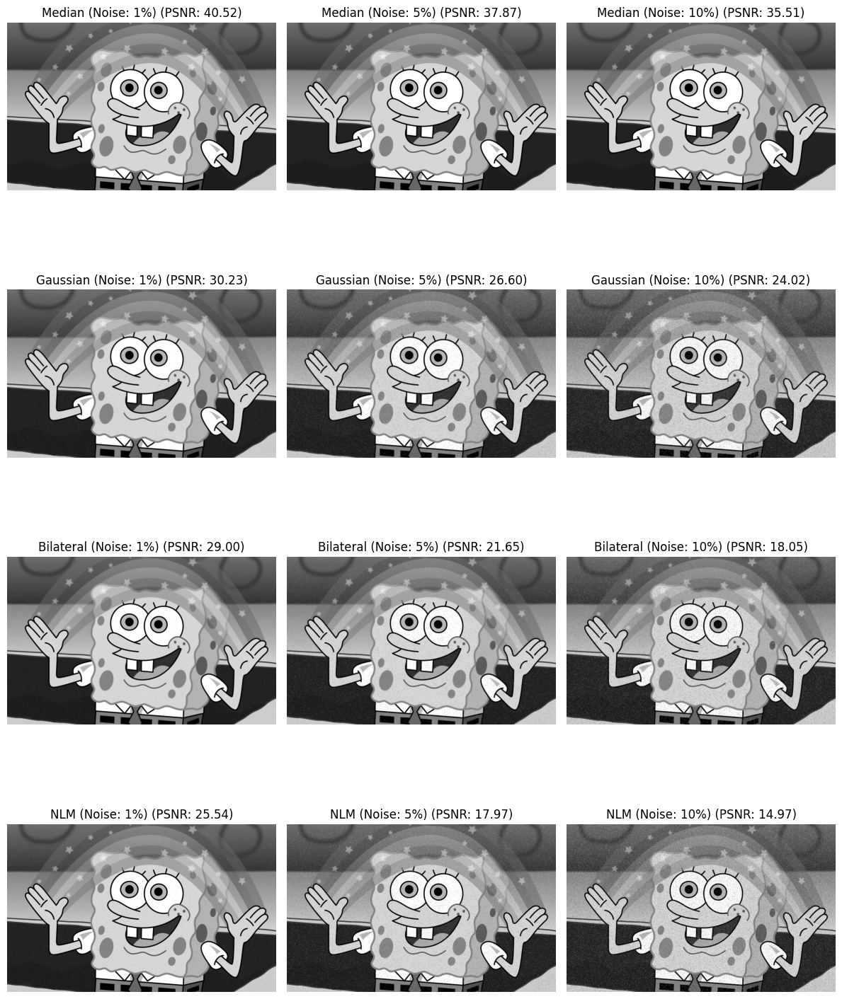

In [107]:
noise_levels = [0.01, 0.05, 0.1]
filter_names = ['Median Filter', 'Gaussian Filter', 'Bilateral Filter', 'Non-Local Means']

fig, axes = plt.subplots(4, 3, figsize=(12, 16))

for col, amount in enumerate(noise_levels):
    noisy_img = add_salt_pepper_noise(img, amount=amount)

    # Median filter (5x5)
    median = cv2.medianBlur(noisy_img, 5)
    median_psnr = calculate_psnr(img, median)
    axes[0, col].imshow(median, cmap='gray')
    axes[0, col].set_title(f'Median (Noise: {amount*100:.0f}%) (PSNR: {median_psnr:.2f})')
    axes[0, col].axis('off')

    # Gaussian filter (5x5, sigma=0)
    gaussian = cv2.GaussianBlur(noisy_img, (5,5), 0)
    gaussian_psnr = calculate_psnr(img, gaussian)
    axes[1, col].imshow(gaussian, cmap='gray')
    axes[1, col].set_title(f'Gaussian (Noise: {amount*100:.0f}%) (PSNR: {gaussian_psnr:.2f})')
    axes[1, col].axis('off')

    # Bilateral filter (d=9, sigmaColor=75, sigmaSpace=75)
    bilateral = cv2.bilateralFilter(noisy_img, 9, 75, 75)
    bilateral_psnr = calculate_psnr(img, bilateral)
    axes[2, col].imshow(bilateral, cmap='gray')
    axes[2, col].set_title(f'Bilateral (Noise: {amount*100:.0f}%) (PSNR: {bilateral_psnr:.2f})')
    axes[2, col].axis('off')

    # Non-Local Means denoising (optional)
    nlm = cv2.fastNlMeansDenoising(noisy_img, h=10, templateWindowSize=7, searchWindowSize=21)
    nlm_psnr = calculate_psnr(img, nlm)
    
    axes[3, col].imshow(nlm, cmap='gray')
    axes[3, col].set_title(f'NLM (Noise: {amount*100:.0f}%) (PSNR: {nlm_psnr:.2f})')
    axes[3, col].axis('off')

plt.tight_layout()
plt.show()

Overall, the **Median filter** performed the best, achieving the highest **PSNR** across all three noise levels. This is expected because **median filtering** is particularly effective at removing salt-and-pepper noise, as it replaces each pixel with the median of its neighbors, preserving edges while eliminating isolated noise spikes.  

**Non-Local Means denoising**, on the other hand, performed the worst, likely because it is optimized for Gaussian or normally distributed noise, and salt-and-pepper noise violates its assumptions, leading to poorer reconstruction.  

Comparing the **Bilateral** and **Gaussian filters**, both performed similarly at low noise levels (1%), with only a minor difference in **PSNR**. However, as the noise increased, the **PSNR** difference widened, with the **Bilateral filter** degrading faster.  

This occurs because the **Bilateral filter** relies on both spatial closeness and intensity similarity, and when the noise becomes strong, the intensity differences caused by salt-and-pepper noise reduce its ability to smooth effectively, whereas the **Gaussian filter** applies uniform smoothing, which, although blurring the image, is less sensitive to extreme pixel values.


## Task 4: Motion Blur Simulation and Analysis

In [108]:
img = cv2.imread(peppers_img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [109]:
def create_motion_blur_kernel(size, angle):
    kernel = np.zeros((size, size))
    center = size // 2
    
    # Convert angle to radians
    angle_rad = np.deg2rad(angle)
    
    # Create line along the angle
    for i in range(size):
        offset = i - center
        x = int(center + offset * np.cos(angle_rad))
        y = int(center + offset * np.sin(angle_rad))
        
        if 0 <= x < size and 0 <= y < size:
            kernel[y, x] = 1
    
    # Normalize
    kernel /= np.sum(kernel)
    
    return kernel


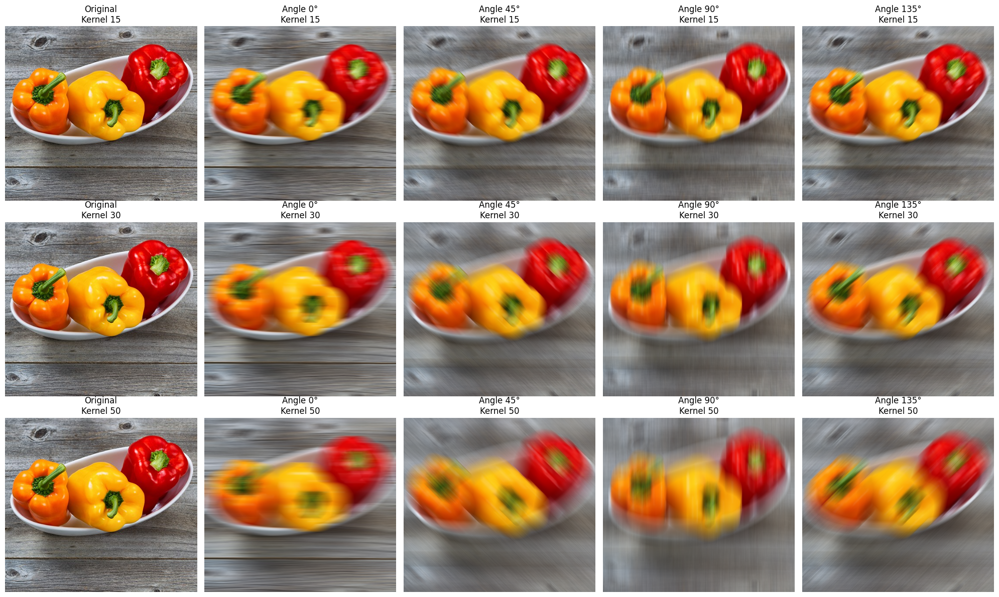

In [ ]:
kernel_sizes = [15, 30, 50]
angles = [0, 45, 90, 135]

rows = len(kernel_sizes)        # each row = a different kernel size
cols = len(angles) + 1          # first column = original image
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
axes = axes.flatten() if rows > 1 else axes  

for r, size in enumerate(kernel_sizes):
    # First column = original image
    axes[r*cols].imshow(img_rgb)
    axes[r*cols].set_title(f"Original\nKernel {size}")
    axes[r*cols].axis('off')
    
    for c, angle in enumerate(angles):
        # Create motion blur kernel
        kernel = create_motion_blur_kernel(size, angle)
        
        # Apply filter to each channel
        blurred = np.zeros_like(img_rgb)
        for ch in range(3):
            blurred[..., ch] = cv2.filter2D(img_rgb[..., ch], -1, kernel)
        
        # Show blurred image with both kernel size and angle
        axes[r*cols + c + 1].imshow(blurred)
        axes[r*cols + c + 1].set_title(f"Angle {angle}°\nKernel {size}")
        axes[r*cols + c + 1].axis('off')

plt.tight_layout()
plt.show()


The higher the kernel, the higher is the angle blur effect

## Task 5: Frequency Domain Filtering with Fourier Transform

In [111]:
def frequency_filter_comparison(image):
    # Load image
    rows, cols = image.shape
    crow, ccol = rows // 2, cols // 2

    # Fourier Transform
    f_transform = np.fft.fft2(image)
    f_shift = np.fft.fftshift(f_transform)
    magnitude_spectrum = 20 * np.log(np.abs(f_shift) + 1)

    cutoffs = [30, 60, 100]
    fig, axes = plt.subplots(6, len(cutoffs), figsize=(20, 22))

    titles = [
        'Original Image',
        'Low-Pass Filtered',
        'High-Pass Filtered',
        'Magnitude Spectrum',
        'Low-Pass Magnitude',
        'High-Pass Magnitude'
    ]

    for j, cutoff in enumerate(cutoffs):
        # Low-pass mask
        lowpass_mask = np.zeros((rows, cols), np.uint8)
        cv2.circle(lowpass_mask, (ccol, crow), cutoff, 1, -1)
        f_shift_low = f_shift * lowpass_mask
        f_ishift_low = np.fft.ifftshift(f_shift_low)
        img_low = np.abs(np.fft.ifft2(f_ishift_low))
        mag_low = 20 * np.log(np.abs(f_shift_low) + 1)

        # High-pass mask
        highpass_mask = np.ones((rows, cols), np.uint8)
        cv2.circle(highpass_mask, (ccol, crow), cutoff, 0, -1)
        f_shift_high = f_shift * highpass_mask
        f_ishift_high = np.fft.ifftshift(f_shift_high)
        img_high = np.abs(np.fft.ifft2(f_ishift_high))
        mag_high = 20 * np.log(np.abs(f_shift_high) + 1)

        # Row 0: Original image
        axes[0, j].imshow(image, cmap='gray')
        axes[0, j].set_title(f'{titles[0]}\nCutoff: {cutoff}')
        axes[0, j].axis('off')

        # Row 1: Low-pass filtered image
        axes[1, j].imshow(img_low, cmap='gray')
        axes[1, j].set_title(f'{titles[1]}\nCutoff: {cutoff}')
        axes[1, j].axis('off')

        # Row 2: High-pass filtered image
        axes[2, j].imshow(img_high, cmap='gray')
        axes[2, j].set_title(f'{titles[2]}\nCutoff: {cutoff}')
        axes[2, j].axis('off')

        # Row 3: Magnitude spectrum (original)
        axes[3, j].imshow(magnitude_spectrum, cmap='gray')
        axes[3, j].set_title(f'{titles[3]}\nCutoff: {cutoff}')
        axes[3, j].axis('off')

        # Row 4: Magnitude spectrum (low-pass)
        axes[4, j].imshow(mag_low, cmap='gray')
        axes[4, j].set_title(f'{titles[4]}\nCutoff: {cutoff}')
        axes[4, j].axis('off')

        # Row 5: Magnitude spectrum (high-pass)
        axes[5, j].imshow(mag_high, cmap='gray')
        axes[5, j].set_title(f'{titles[5]}\nCutoff: {cutoff}')
        axes[5, j].axis('off')

    plt.tight_layout(pad=3.0)
    plt.show()


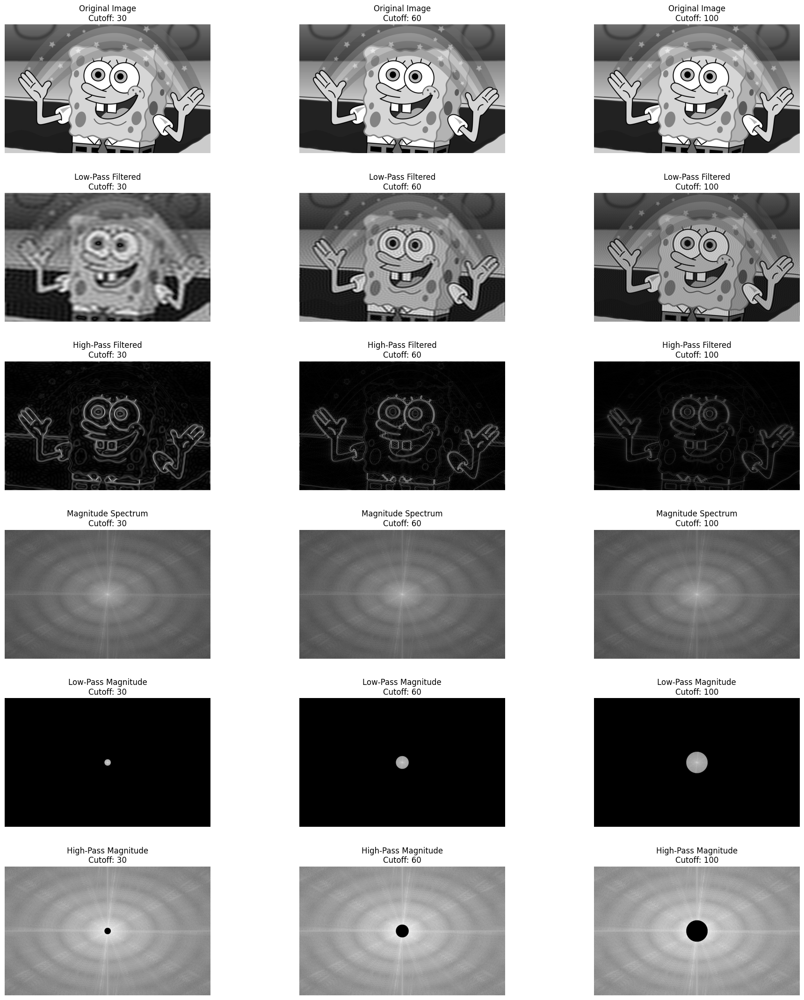

In [112]:
img = cv2.imread(spongebob_img_path,  cv2.IMREAD_GRAYSCALE)
frequency_filter_comparison(img)

In high-pass filters, higher cutoffs make edges and fine details more visible and only more clear edges are preserved, because more high-frequency information is kept. In low-pass filters, higher cutoffs make the image less blurry, since it allows more frequencies  to pass through.
